In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/demo2.png
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/demo4.png
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/S_Image_133.jpg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/images (4).jpeg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/Image_22.jpg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/S_Image_17.jpg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/image (16).jpeg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick/S_Image_268.jpg
/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images/Free_Kick

In [2]:
# ==========================================
# 1. IMPORTS & CONFIGURATION (FIXED)
# ==========================================
import os
import random
import time
import copy
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile  # Added ImageFile
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models
import cv2

# CRITICAL FIX: Tells Pillow to load images even if they are truncated/corrupted
ImageFile.LOAD_TRUNCATED_IMAGES = True

warnings.filterwarnings('ignore')

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

SEED = 42
seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.device_count() > 1:
    print(f"🚀 Dual GPUs detected! Using {torch.cuda.device_count()} x Tesla T4 GPUs via DataParallel.")

CONFIG = {
    'input_shape': (224, 224),
    'batch_size': 64,
    'epochs': 15,
    'lr': 0.001,
    'num_classes': None,
    'dataset_path': '/kaggle/input/soccer-event-classification-image-data-cnn-and-llm/Soccer Event Classification'
}

🚀 Dual GPUs detected! Using 2 x Tesla T4 GPUs via DataParallel.


option 2
Total Images Found: 6128
Number of Classes: 7
Class Mapping: {'Corner_Kick': 0, 'Free_Kick': 1, 'Penalty_kick': 2, 'Red_Card': 3, 'Yellow_Card': 4, 'substitute': 5, 'tackle': 6}


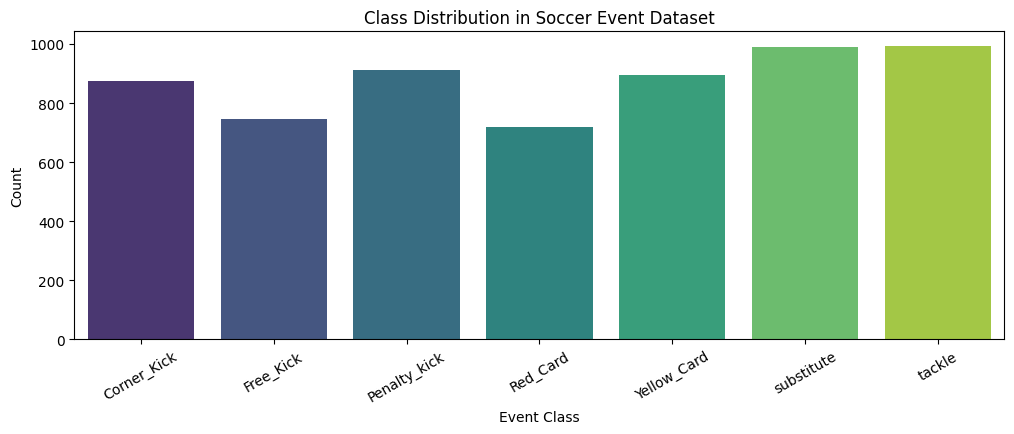

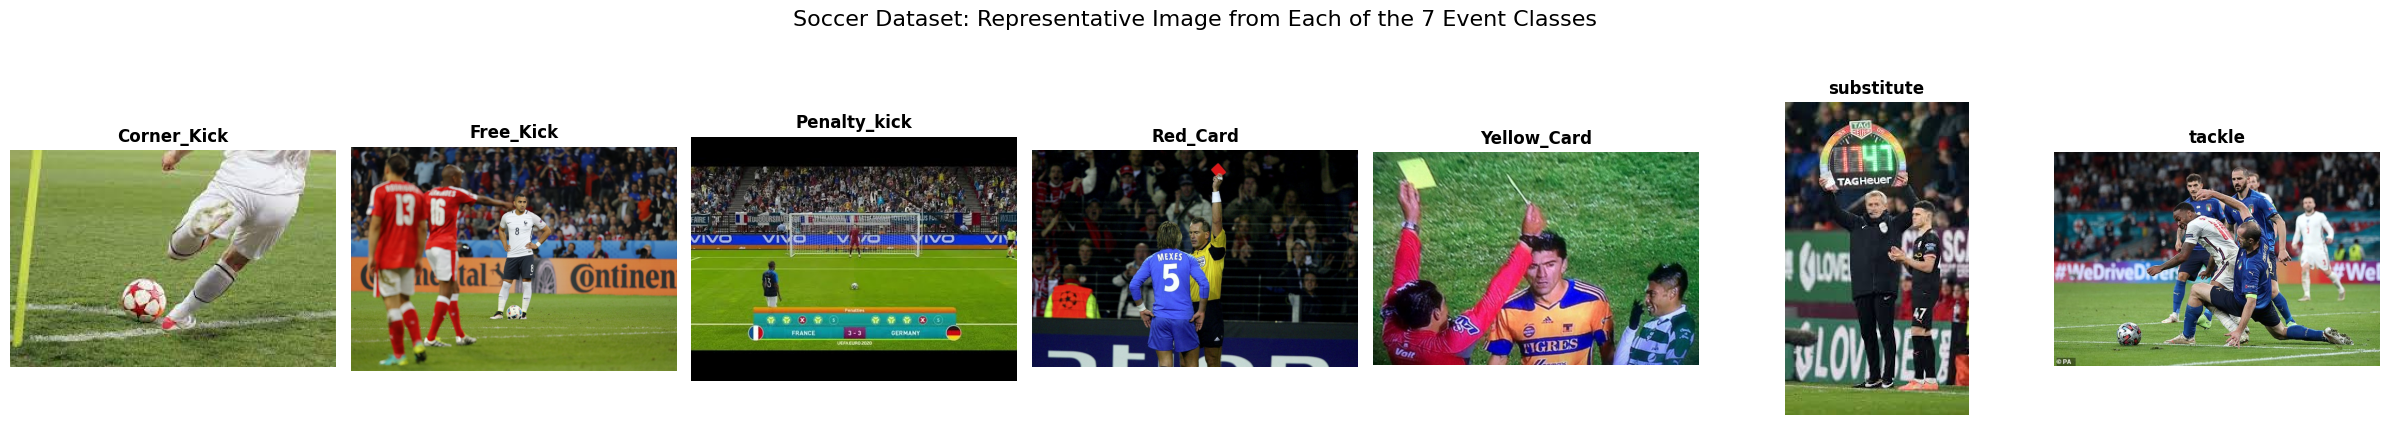

In [3]:
# ==========================================
# 2. DATASET LOADING & EDA
# ==========================================
image_paths = []
labels = []

# Scan dataset directory
if os.path.exists(CONFIG['dataset_path']):
    print('option 1')
    for class_name in os.listdir(CONFIG['CONFIG']['dataset_path'] if 'CONFIG' not in CONFIG else CONFIG['dataset_path']):
        class_dir = os.path.join(CONFIG['dataset_path'], class_name)
        if os.path.isdir(class_dir):
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('png', 'jpg', 'jpeg')):
                    image_paths.append(os.path.join(class_dir, img_name))
                    labels.append(class_name)
else:
    # Fallback to general scanning if path structure varies slightly
    base_path = '/kaggle/input/datasets/rishintiw/soccer-event-classification-image-data-cnn-and-llm/images'
    print('option 2')
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')) and 'soccer' in root.lower() and not file.lower().startswith("demo"):
                image_paths.append(os.path.join(root, file))
                labels.append(os.path.basename(root))

# Create DataFrame
df = pd.DataFrame({'image_path': image_paths, 'label': labels})
unique_classes = sorted(df['label'].unique())
CONFIG['num_classes'] = len(unique_classes)
class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
df['label_idx'] = df['label'].map(class_to_idx)

print(f"Total Images Found: {len(df)}")
print(f"Number of Classes: {CONFIG['num_classes']}")
print(f"Class Mapping: {class_to_idx}")



# Plot Class Distribution
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='label', order=unique_classes, palette='viridis')
plt.title('Class Distribution in Soccer Event Dataset')
plt.xlabel('Event Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

# Display One Sample Image From Each Class (7 Classes Total)
fig, axes = plt.subplots(1, CONFIG['num_classes'], figsize=(24, 4))

for idx, class_name in enumerate(unique_classes):
    # Filter the dataframe for the current class and sample exactly 1 row
    class_sample = df[df['label'] == class_name].sample(1, random_state=SEED).iloc[0]
    
    # Load and render image
    img = Image.open(class_sample['image_path']).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Soccer Dataset: Representative Image from Each of the 7 Event Classes', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Splits: Train(4289) | Val(919) | Test(920)
🎬 Initiating Preprocessing Evaluation Matrix for 3 Soccer Events...


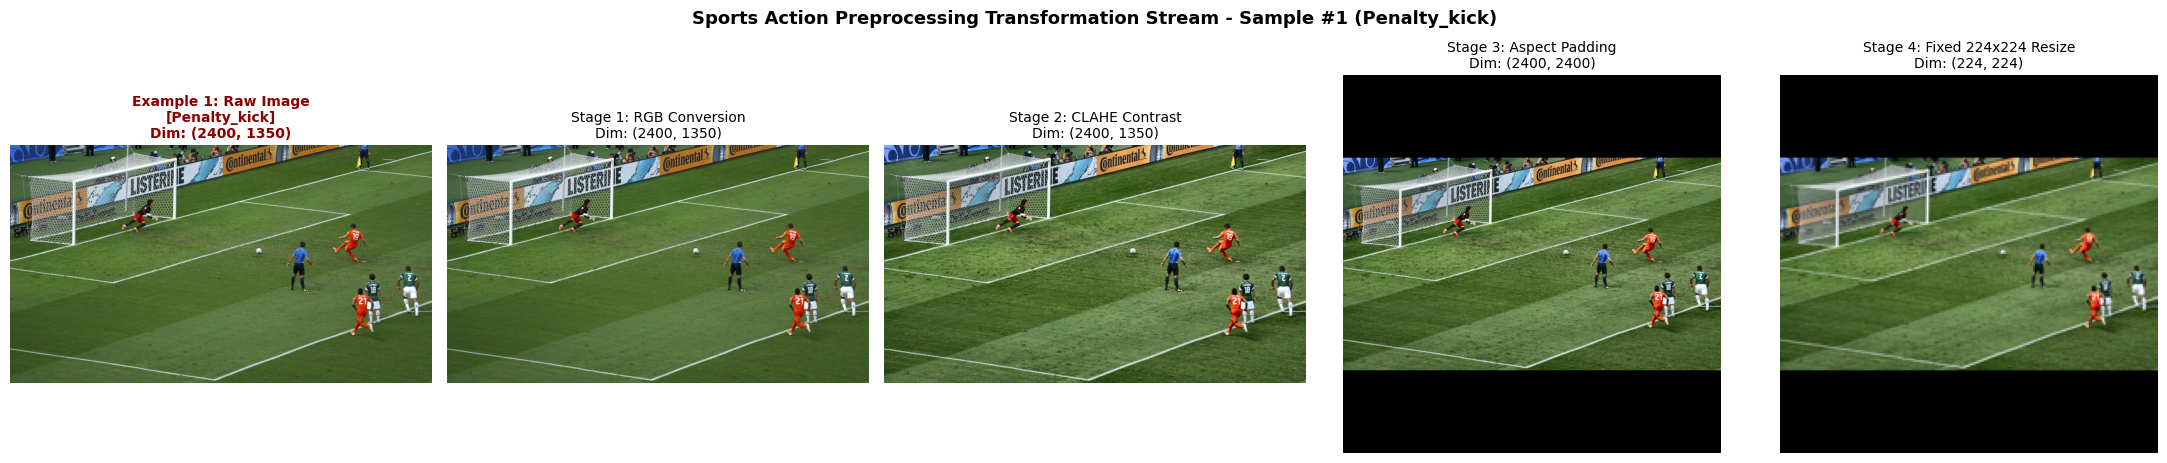

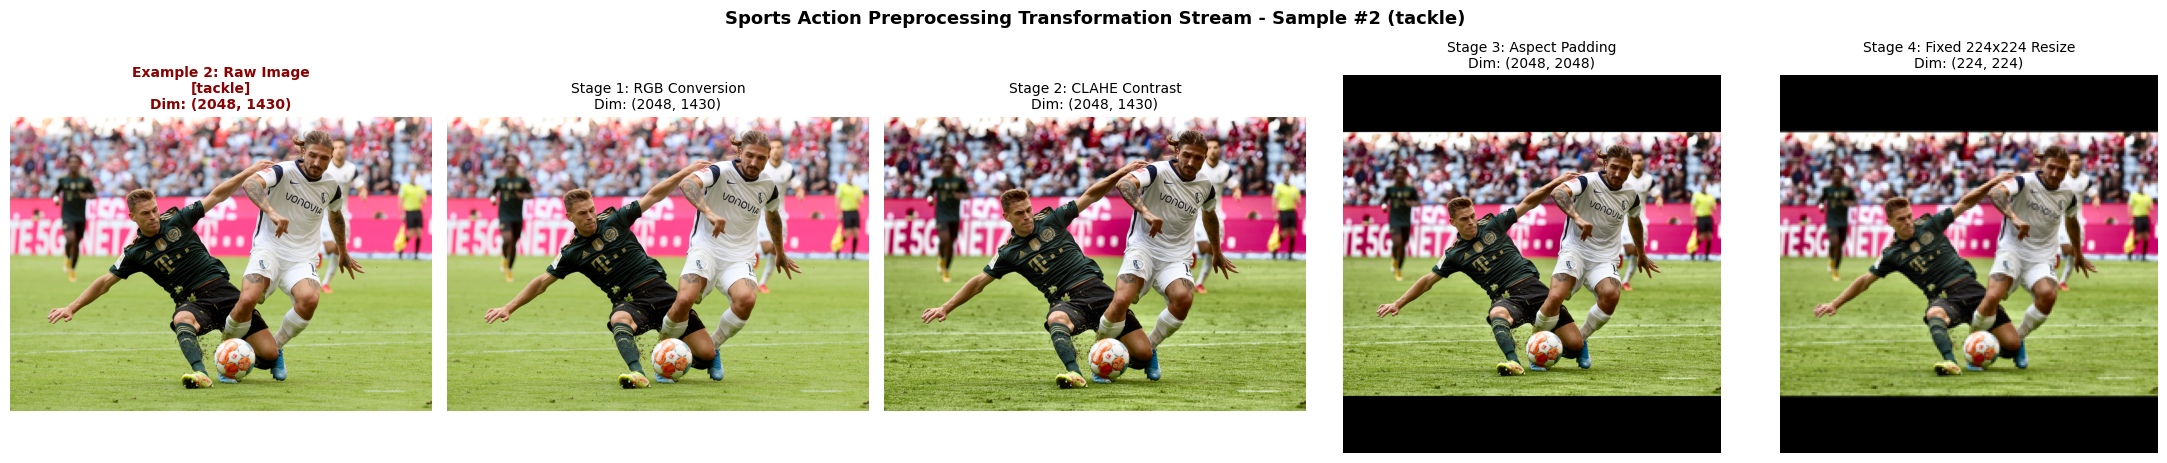

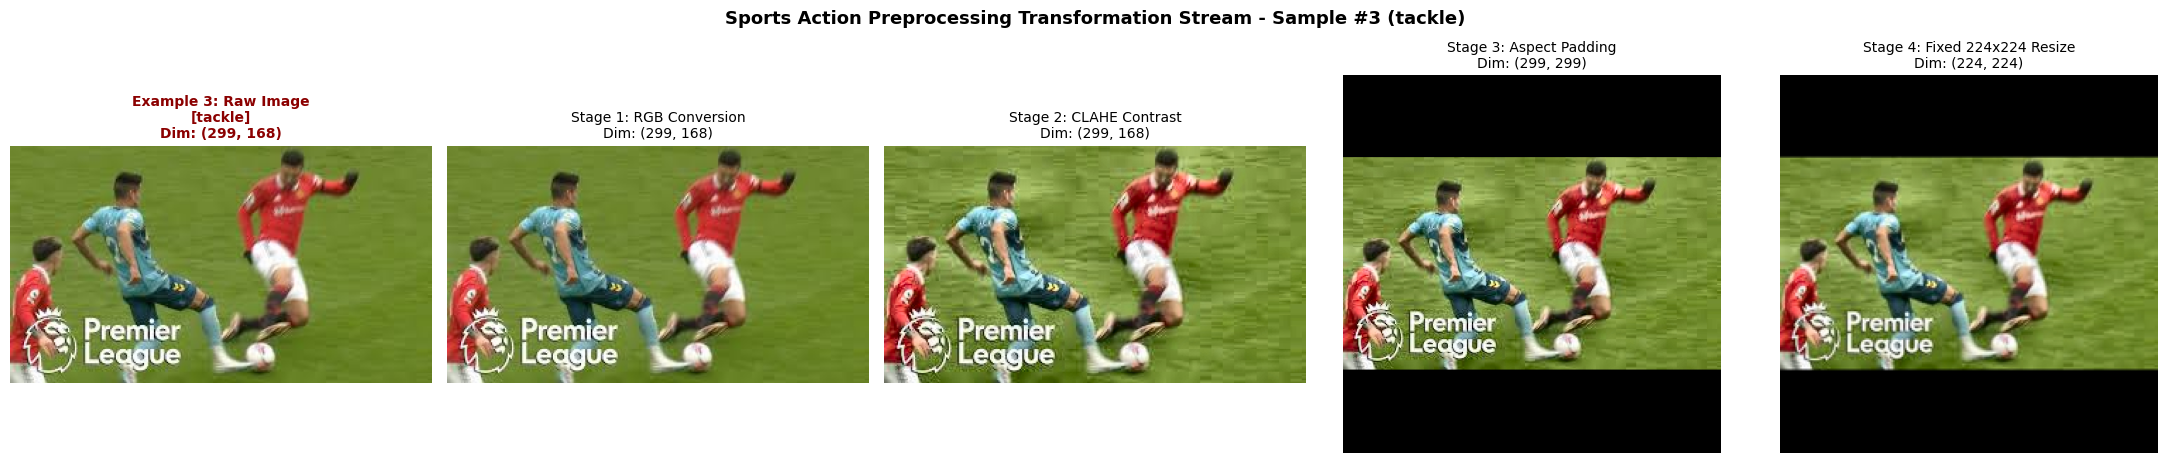

In [4]:
# ==========================================
# 3. PREPROCESSING & DATASET SPLIT (VISUAL PIPELINE)
# ==========================================
import torchvision.transforms.functional as F

# Stratified Dataset Partitioning (70% Train, 15% Validation, 15% Testing)
train_df, test_val_df = train_test_split(df, test_size=0.30, stratify=df['label_idx'], random_state=SEED)
val_df, test_df = train_test_split(test_val_df, test_size=0.50, stratify=test_val_df['label_idx'], random_state=SEED)

print(f"Splits: Train({len(train_df)}) | Val({len(val_df)}) | Test({len(test_df)})")

def advanced_sports_preprocess_stepped(pil_img, target_size=(224, 224)):
    """
    Executes advanced preprocessing stages while keeping copies of each matrix step
    to visually demonstrate the sports engineering pipeline for documentation.
    """
    stages = {}
    
    # STAGE 1: Raw File Channel Isolation & Standard RGB Conversion
    # (Strips out unpredictable alpha transparency channels from web-scrapes or raw data)
    img_rgb = pil_img.convert('RGB')
    stages['Stage 1: RGB Conversion'] = img_rgb.copy()
    
    # STAGE 2: Advanced Localized Contrast Optimization (CLAHE)
    # (Neutralizes harsh stadium floodlight glare or deep afternoon shadows on the pitch)
    open_cv_image = np.array(img_rgb)
    lab = cv2.cvtColor(open_cv_image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    enhanced_rgb = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    img_clahe = Image.fromarray(enhanced_rgb)
    stages['Stage 2: CLAHE Contrast'] = img_clahe.copy()
    
    # STAGE 3: Structural Aspect-Ratio Square Border Padding
    # (Pads the shorter axis to preserve exact skeletal angles/postures of moving players)
    w, h = img_clahe.size
    if w == h:
        img_padded = img_clahe.copy()
    else:
        max_side = max(w, h)
        pad_w = max_side - w
        pad_h = max_side - h
        padding = (pad_w // 2, pad_h // 2, pad_w - (pad_w // 2), pad_h - (pad_h // 2))
        img_padded = F.pad(img_clahe, padding, fill=0) # Pad with neutral stadium black borders
    stages['Stage 3: Aspect Padding'] = img_padded.copy()
    
    # STAGE 4: Uniform Dimensional Spatial Downsampling
    # (Resizes cleanly to a fixed 224x224 input grid for downstream CNN/Transfer models)
    img_resized = img_padded.resize(target_size)
    stages['Stage 4: Fixed 224x224 Resize'] = img_resized.copy()
    
    return img_resized, stages

class SoccerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            img_path = self.df.loc[idx, 'image_path']
            raw_image = Image.open(img_path)
            
            # Pass image through advanced preprocessing sequence
            processed_image, _ = advanced_sports_preprocess_stepped(raw_image, CONFIG['input_shape'])
            label = int(self.df.loc[idx, 'label_idx'])
            
            if self.transform:
                processed_image = self.transform(processed_image)
                
            return processed_image, label
            
        except Exception as e:
            # Defensive Failure Bypass: Instantly fall back to a random clean file if corruption hits
            random_idx = random.randint(0, len(self.df) - 1)
            return self.__getitem__(random_idx)

# =====================================================================
# PIPELINE DEMONSTRATION: SHOWING 3 UNIQUE EXAMPLES ACROSS ALL STAGES
# =====================================================================
def generate_pipeline_reports(dataframe, num_examples=3):
    print(f"🎬 Initiating Preprocessing Evaluation Matrix for {num_examples} Soccer Events...")
    
    for ex in range(num_examples):
        # Sample a unique random row index
        rand_idx = random.randint(0, len(dataframe) - 1)
        row = dataframe.iloc[rand_idx]
        img_path = row['image_path']
        class_label = row['label']
        
        try:
            raw_img = Image.open(img_path)
            # Run the extraction method
            _, pipeline_stages = advanced_sports_preprocess_stepped(raw_img, CONFIG['input_shape'])
            
            # Construct a 5-column visualization row (Raw + 4 Stages)
            fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
            
            # Column 0: Original State
            axes[0].imshow(raw_img)
            axes[0].set_title(f"Example {ex+1}: Raw Image\n[{class_label}]\nDim: {raw_img.size}", fontsize=10, color='darkred', fontweight='bold')
            axes[0].axis('off')
            
            # Columns 1 to 4: Chronological Preprocessing Stages
            for s_idx, (stage_name, stage_img) in enumerate(pipeline_stages.items(), start=1):
                axes[s_idx].imshow(stage_img)
                axes[s_idx].set_title(f"{stage_name}\nDim: {stage_img.size}", fontsize=10, fontweight='medium')
                axes[s_idx].axis('off')
                
            plt.suptitle(f"Sports Action Preprocessing Transformation Stream - Sample #{ex+1} ({class_label})", fontsize=13, y=1.02, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f'preprocessing_evolution_sample_{ex+1}.png', bbox_inches='tight')
            plt.show()
            
        except Exception as e:
            print(f"Skipping random sample row index {rand_idx} due to temporary read error: {e}")

# Run the 3-example diagnostic pipeline display
generate_pipeline_reports(train_df, num_examples=3)

DataLoader initialization successful. `drop_last=True` implemented on train partition to defend multi-GPU BatchNorm channels.
📊 DYNAMIC AUGMENTATION ENGINE TRACKING SUMMARY
Total Static Training Images: 4289
Planned Training Epochs:      15


,Class Name,Base Train Images,Dynamic Variants Exposed (Total Run)
0,Corner_Kick,612,9180
1,Free_Kick,521,7815
2,Penalty_kick,638,9570
3,Red_Card,503,7545
4,Yellow_Card,627,9405
5,substitute,693,10395
6,tackle,695,10425


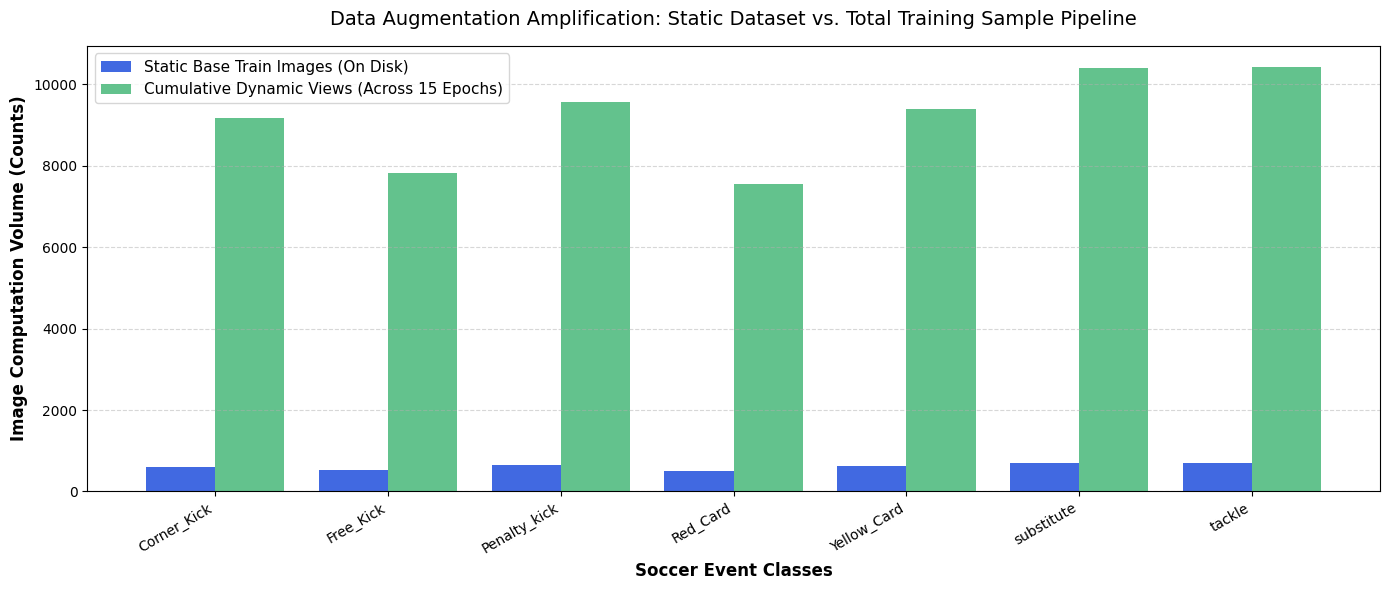

🚀 Execution Check: The green bars are now scaled by a factor of 15x.
Over the full run, the CNN parses a cumulative total of 64335 dynamically unique matrix states.


In [10]:
# ==========================================
# 4. DATA AUGMENTATION & GENERATORS (FIXED FOR MULTI-GPU BATCHNORM)
# ==========================================

# Define Sports-Specific Augmentations and Core Normalization
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),      # Simulates alternate attack directions
    transforms.RandomRotation(degrees=15),       # Simulates camera tilt and player body lean
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Dataset Instances
train_dataset = SoccerDataset(train_df, transform=train_transforms)
val_dataset = SoccerDataset(val_df, transform=val_test_transforms)
test_dataset = SoccerDataset(test_df, transform=val_test_transforms)

# Initialize Optimized DataLoaders 
# CRITICAL FIX: Added drop_last=True to train_loader to prevent single-item batches on multi-GPU training
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

print("DataLoader initialization successful. `drop_last=True` implemented on train partition to defend multi-GPU BatchNorm channels.")

# Calculate and display the on-the-fly dynamic data metrics
print("=====================================================================")
print("📊 DYNAMIC AUGMENTATION ENGINE TRACKING SUMMARY")
print("=====================================================================")
print(f"Total Static Training Images: {len(train_df)}")
print(f"Planned Training Epochs:      {CONFIG['epochs']}")

# Compute exact distributions across classes
augmentation_summary = []
for class_name in unique_classes:
    base_count = len(train_df[train_df['label'] == class_name])
    # Total unique variations seen by the network across the whole training timeline
    total_dynamic_variants = base_count * CONFIG['epochs']
    
    augmentation_summary.append({
        'Class Name': class_name,
        'Base Train Images': base_count,
        'Dynamic Variants Exposed (Total Run)': total_dynamic_variants
    })

aug_df = pd.DataFrame(augmentation_summary)
display(aug_df)

# Plot the comparative impact of data augmentation per class
plt.figure(figsize=(14, 6))
x_axis = np.arange(len(unique_classes))

# 1. Base Static Images
plt.bar(x_axis - 0.2, aug_df['Base Train Images'], width=0.4, 
        label='Static Base Train Images (On Disk)', color='royalblue')

# 2. Total Cumulative Augmented Variations (Corrected scale to show accumulation over epochs)
plt.bar(x_axis + 0.2, aug_df['Dynamic Variants Exposed (Total Run)'], width=0.4, 
        label='Cumulative Dynamic Views (Across 15 Epochs)', color='emerald' if 'emerald' in locals() else 'mediumseagreen', alpha=0.8)

# Formatting the output chart
plt.xticks(x_axis, unique_classes, rotation=30, ha='right')
plt.xlabel('Soccer Event Classes', fontsize=12, fontweight='bold')
plt.ylabel('Image Computation Volume (Counts)', fontsize=12, fontweight='bold')
plt.title('Data Augmentation Amplification: Static Dataset vs. Total Training Sample Pipeline', fontsize=14, pad=15)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('data_augmentation_distribution_fixed.png')
plt.show()

print(f"🚀 Execution Check: The green bars are now scaled by a factor of {CONFIG['epochs']}x.")
print(f"Over the full run, the CNN parses a cumulative total of {aug_df['Dynamic Variants Exposed (Total Run)'].sum()} dynamically unique matrix states.")
print("=====================================================================")

In [6]:
# ==========================================
# 5. CUSTOM CNN ARCHITECTURE & TRAINING
# ==========================================
class CustomSoccerCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomSoccerCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Global Avg Pooling instead of massive Linear flattening
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Multi-GPU Engine Training Loop Template
def train_model(model, criterion, optimizer, num_epochs=15, model_name='model'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time.time()
        # Train Phase
        model.train()
        running_loss, running_corrects = 0.0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        running_vloss, running_vcorrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                running_vloss += loss.item() * inputs.size(0)
                running_vcorrects += torch.sum(preds == labels.data)
                
        epoch_val_loss = running_vloss / len(val_loader.dataset)
        epoch_val_acc = running_vcorrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.item())

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} [{elapsed:.1f}s] -> "
              f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f"🏆 {model_name} Best Val Acc: {best_acc:.4f}")
    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), f"{model_name}_best.pth")
    return model, history

print("Initializing Custom CNN...")
custom_model = CustomSoccerCNN(CONFIG['num_classes'])
if torch.cuda.device_count() > 1:
    custom_model = nn.DataParallel(custom_model)
custom_model = custom_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(custom_model.parameters(), lr=CONFIG['lr'])

custom_model, custom_history = train_model(
    custom_model, criterion, optimizer, num_epochs=CONFIG['epochs'], model_name='custom_cnn'
)

Initializing Custom CNN...
Epoch 1/15 [156.6s] -> Train Loss: 1.5929 Acc: 0.3404 | Val Loss: 1.5691 Acc: 0.4244
Epoch 2/15 [151.2s] -> Train Loss: 1.3921 Acc: 0.4493 | Val Loss: 1.3828 Acc: 0.4124
Epoch 3/15 [155.3s] -> Train Loss: 1.3037 Acc: 0.4976 | Val Loss: 1.3521 Acc: 0.4592
Epoch 4/15 [151.5s] -> Train Loss: 1.2368 Acc: 0.5286 | Val Loss: 1.1320 Acc: 0.5822
Epoch 5/15 [152.2s] -> Train Loss: 1.1926 Acc: 0.5472 | Val Loss: 1.2268 Acc: 0.5484
Epoch 6/15 [150.9s] -> Train Loss: 1.1417 Acc: 0.5782 | Val Loss: 1.1520 Acc: 0.5778
Epoch 7/15 [154.4s] -> Train Loss: 1.1521 Acc: 0.5631 | Val Loss: 1.3659 Acc: 0.5136
Epoch 8/15 [152.9s] -> Train Loss: 1.1226 Acc: 0.5803 | Val Loss: 1.2202 Acc: 0.5484
Epoch 9/15 [153.8s] -> Train Loss: 1.0563 Acc: 0.6027 | Val Loss: 1.1072 Acc: 0.5756
Epoch 10/15 [153.1s] -> Train Loss: 1.0773 Acc: 0.5959 | Val Loss: 1.2099 Acc: 0.5669
Epoch 11/15 [156.2s] -> Train Loss: 1.0608 Acc: 0.6106 | Val Loss: 1.0265 Acc: 0.6028
Epoch 12/15 [153.3s] -> Train Loss: 

In [7]:
# ==========================================
# 6. TRANSFER LEARNING — VERSION 1 (ResNet18)
# ==========================================
print("Initializing ResNet18 (Transfer Learning V1)...")
resnet_model = models.resnet18(pretrained=True)

# Freeze lower layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Reconstruct Final Classification Head
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, CONFIG['num_classes'])
)

if torch.cuda.device_count() > 1:
    resnet_model = nn.DataParallel(resnet_model)
resnet_model = resnet_model.to(device)

optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=CONFIG['lr'])
resnet_model, resnet_history = train_model(
    resnet_model, criterion, optimizer_resnet, num_epochs=CONFIG['epochs'], model_name='resnet18'
)

Initializing ResNet18 (Transfer Learning V1)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


Epoch 1/15 [151.1s] -> Train Loss: 1.4497 Acc: 0.4465 | Val Loss: 0.9787 Acc: 0.6496
Epoch 2/15 [157.7s] -> Train Loss: 1.0626 Acc: 0.6029 | Val Loss: 0.9429 Acc: 0.6181
Epoch 3/15 [150.8s] -> Train Loss: 0.9816 Acc: 0.6398 | Val Loss: 0.8364 Acc: 0.7084
Epoch 4/15 [150.2s] -> Train Loss: 0.9667 Acc: 0.6482 | Val Loss: 0.8066 Acc: 0.7051
Epoch 5/15 [143.0s] -> Train Loss: 0.9806 Acc: 0.6405 | Val Loss: 0.7847 Acc: 0.7193
Epoch 6/15 [141.1s] -> Train Loss: 0.9196 Acc: 0.6687 | Val Loss: 0.7437 Acc: 0.7301
Epoch 7/15 [140.9s] -> Train Loss: 0.9201 Acc: 0.6640 | Val Loss: 0.7414 Acc: 0.7182
Epoch 8/15 [141.1s] -> Train Loss: 0.8967 Acc: 0.6824 | Val Loss: 0.7229 Acc: 0.7399
Epoch 9/15 [140.5s] -> Train Loss: 0.8520 Acc: 0.6950 | Val Loss: 0.7514 Acc: 0.7323
Epoch 10/15 [140.8s] -> Train Loss: 0.8812 Acc: 0.6761 | Val Loss: 0.7240 Acc: 0.7486
Epoch 11/15 [142.1s] -> Train Loss: 0.8895 Acc: 0.6827 | Val Loss: 0.6870 Acc: 0.7476
Epoch 12/15 [142.7s] -> Train Loss: 0.8372 Acc: 0.6948 | Val Lo

In [11]:
# ==========================================
# 7. TRANSFER LEARNING — VERSION 2 ADVANCED (EfficientNet_B0)
# ==========================================
print("Initializing EfficientNet_B0 with Selective Fine-Tuning (Transfer Learning V2)...")

# Load pre-trained weights
effnet_model = models.efficientnet_b0(pretrained=True)

# Unfreeze blocks 6 and 7 for feature fine-tuning, freeze earlier layers
for param in effnet_model.features.parameters():
    param.requires_grad = False
for block in [effnet_model.features[6], effnet_model.features[7]]:
    for param in block.parameters():
        param.requires_grad = True

# Custom Classification Block
num_ftrs_eff = effnet_model.classifier[1].in_features
effnet_model.classifier = nn.Sequential(
    nn.Linear(num_ftrs_eff, 256),
    nn.BatchNorm1d(256),
    nn.SiLU(),
    nn.Dropout(0.4),
    nn.Linear(256, CONFIG['num_classes'] if CONFIG['num_classes'] else 7)
)

# Distribute architecture graph over Dual GPUs cleanly
if torch.cuda.device_count() > 1:
    effnet_model = nn.DataParallel(effnet_model)
effnet_model = effnet_model.to(device)

# Differential Learning Rates (Lower learning rate for fine-tuning)
optimizer_effnet = optim.Adam(effnet_model.parameters(), lr=CONFIG['lr'] * 0.5)

# Execute Advanced Training
effnet_model, effnet_history = train_model(
    effnet_model, criterion, optimizer_effnet, num_epochs=CONFIG['epochs'], model_name='efficientnet'
)

Initializing EfficientNet_B0 with Selective Fine-Tuning (Transfer Learning V2)...
Epoch 1/15 [150.2s] -> Train Loss: 0.8523 Acc: 0.7053 | Val Loss: 0.4107 Acc: 0.8651
Epoch 2/15 [151.7s] -> Train Loss: 0.4545 Acc: 0.8494 | Val Loss: 0.3918 Acc: 0.8672
Epoch 3/15 [148.2s] -> Train Loss: 0.3515 Acc: 0.8909 | Val Loss: 0.3553 Acc: 0.8672
Epoch 4/15 [151.4s] -> Train Loss: 0.2909 Acc: 0.9079 | Val Loss: 0.3414 Acc: 0.8879
Epoch 5/15 [155.8s] -> Train Loss: 0.2192 Acc: 0.9305 | Val Loss: 0.3669 Acc: 0.8716
Epoch 6/15 [155.0s] -> Train Loss: 0.2104 Acc: 0.9331 | Val Loss: 0.3167 Acc: 0.8923
Epoch 7/15 [156.7s] -> Train Loss: 0.1668 Acc: 0.9459 | Val Loss: 0.3101 Acc: 0.8912
Epoch 8/15 [150.5s] -> Train Loss: 0.1488 Acc: 0.9552 | Val Loss: 0.3389 Acc: 0.8912
Epoch 9/15 [158.0s] -> Train Loss: 0.1334 Acc: 0.9566 | Val Loss: 0.3184 Acc: 0.8999
Epoch 10/15 [152.4s] -> Train Loss: 0.1115 Acc: 0.9639 | Val Loss: 0.3673 Acc: 0.8955
Epoch 11/15 [154.8s] -> Train Loss: 0.1127 Acc: 0.9629 | Val Loss: 

In [12]:
# ==========================================
# 8. MODEL EVALUATION
# ==========================================
def evaluate_on_test(model, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    print(f"\n===== Classification Report: {model_name} =====")
    print(classification_report(all_labels, all_preds, target_names=unique_classes))
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Run testing evaluations
labels_custom, preds_custom, probs_custom = evaluate_on_test(custom_model, "Custom CNN")
labels_resnet, preds_resnet, probs_resnet = evaluate_on_test(resnet_model, "ResNet18 (V1)")
labels_effnet, preds_effnet, probs_effnet = evaluate_on_test(effnet_model, "EfficientNet_B0 (V2)")


===== Classification Report: Custom CNN =====
              precision    recall  f1-score   support

 Corner_Kick       0.62      0.52      0.57       131
   Free_Kick       0.44      0.25      0.32       112
Penalty_kick       0.48      0.74      0.58       137
    Red_Card       0.70      0.66      0.68       107
 Yellow_Card       0.72      0.64      0.68       135
  substitute       0.77      0.89      0.83       149
      tackle       0.85      0.80      0.82       149

    accuracy                           0.66       920
   macro avg       0.66      0.64      0.64       920
weighted avg       0.66      0.66      0.65       920


===== Classification Report: ResNet18 (V1) =====
              precision    recall  f1-score   support

 Corner_Kick       0.60      0.76      0.67       131
   Free_Kick       0.62      0.52      0.56       112
Penalty_kick       0.74      0.61      0.67       137
    Red_Card       0.77      0.70      0.73       107
 Yellow_Card       0.81      0.70  

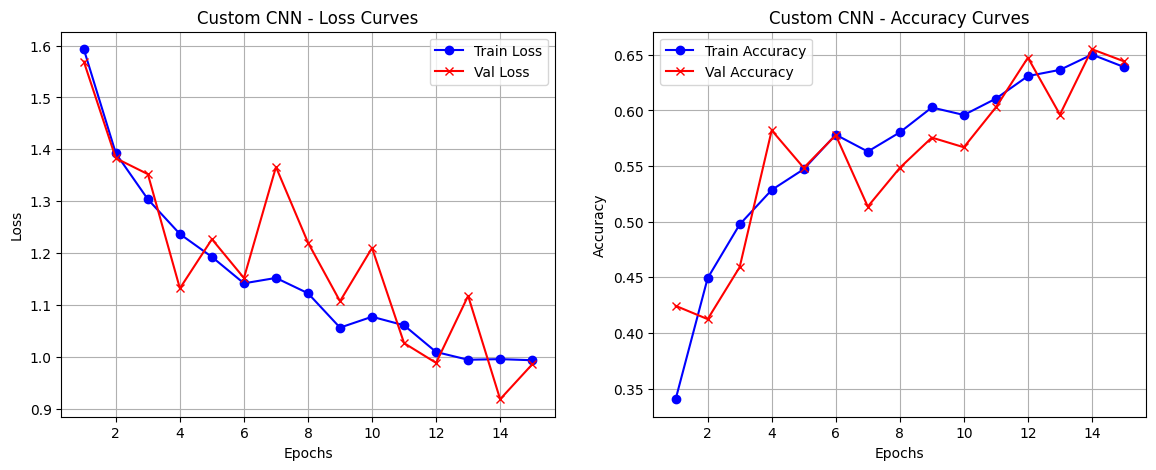

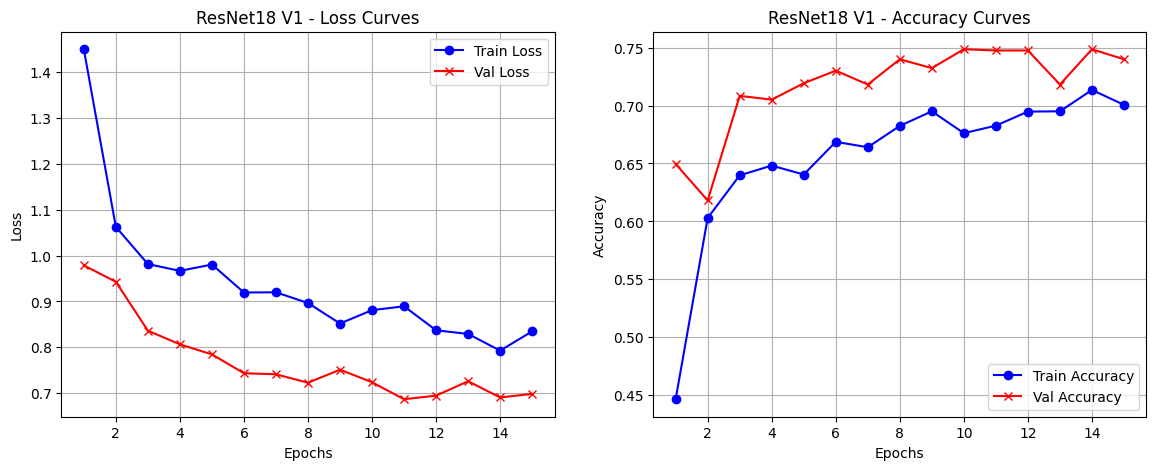

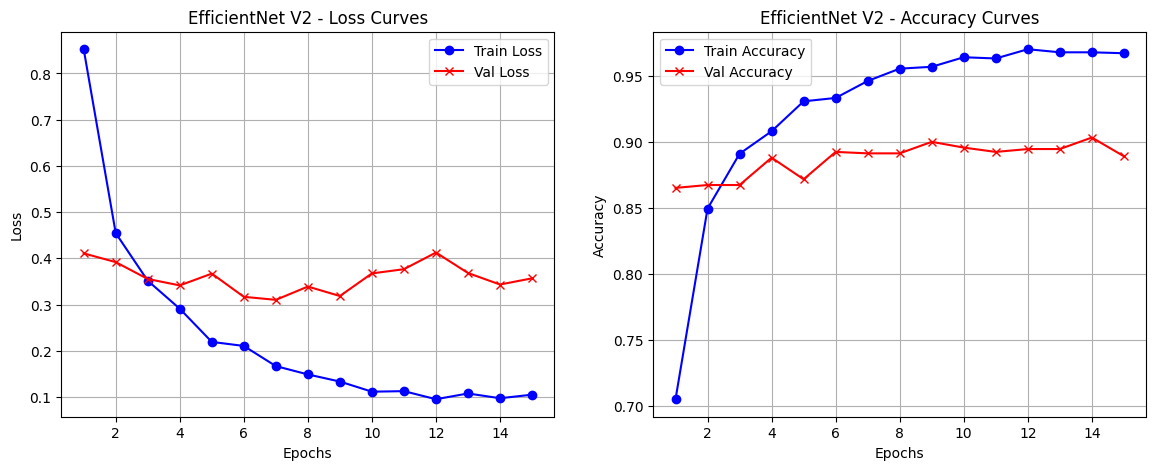

In [13]:
# ==========================================
# 9. TRAINING & VALIDATION CURVES
# ==========================================
def plot_metrics(history, title):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue', marker='o')
    ax1.plot(epochs_range, history['val_loss'], label='Val Loss', color='red', marker='x')
    ax1.set_title(f'{title} - Loss Curves')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy Curve
    ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', color='blue', marker='o')
    ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy', color='red', marker='x')
    ax2.set_title(f'{title} - Accuracy Curves')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.savefig(f"{title.lower().replace(' ', '_')}_curves.png")
    plt.show()

plot_metrics(custom_history, "Custom CNN")
plot_metrics(resnet_history, "ResNet18 V1")
plot_metrics(effnet_history, "EfficientNet V2")

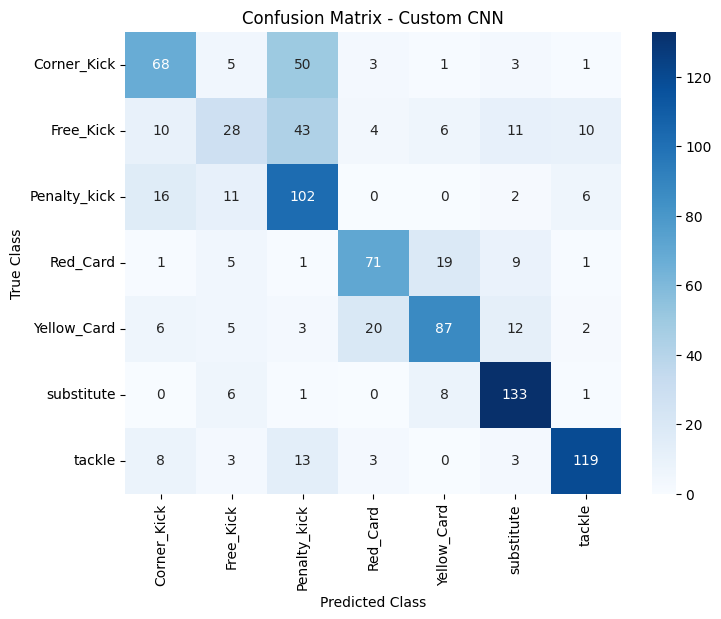

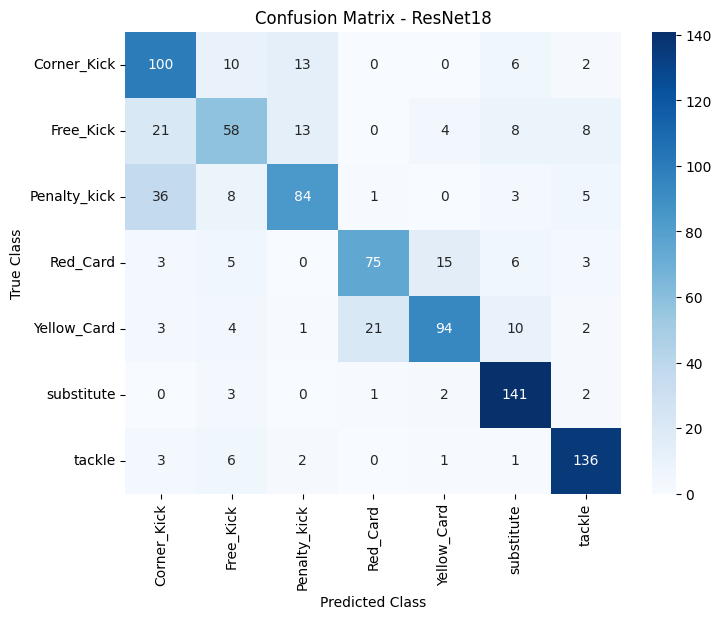

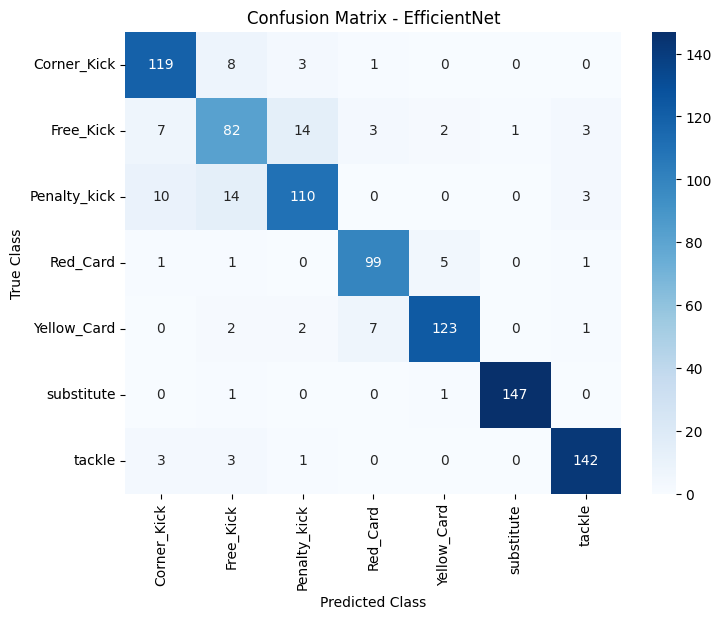

In [14]:
# ==========================================
# 10. CONFUSION MATRICES
# ==========================================
def plot_cm(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_classes, yticklabels=unique_classes)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.savefig(f"{title.lower().replace(' ', '_')}_cm.png", bbox_inches='tight')
    plt.show()

plot_cm(labels_custom, preds_custom, "Custom CNN")
plot_cm(labels_resnet, preds_resnet, "ResNet18")
plot_cm(labels_effnet, preds_effnet, "EfficientNet")

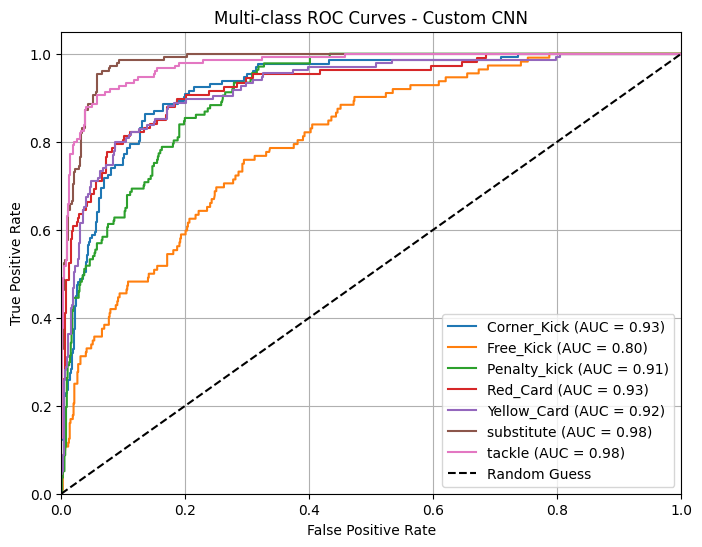

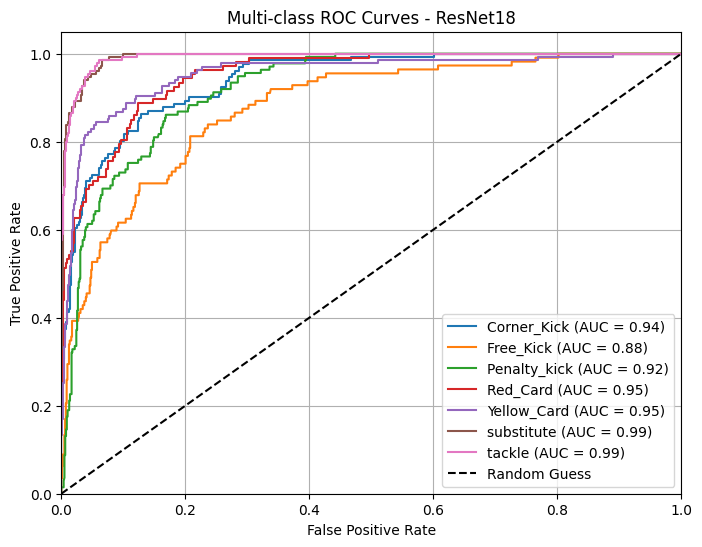

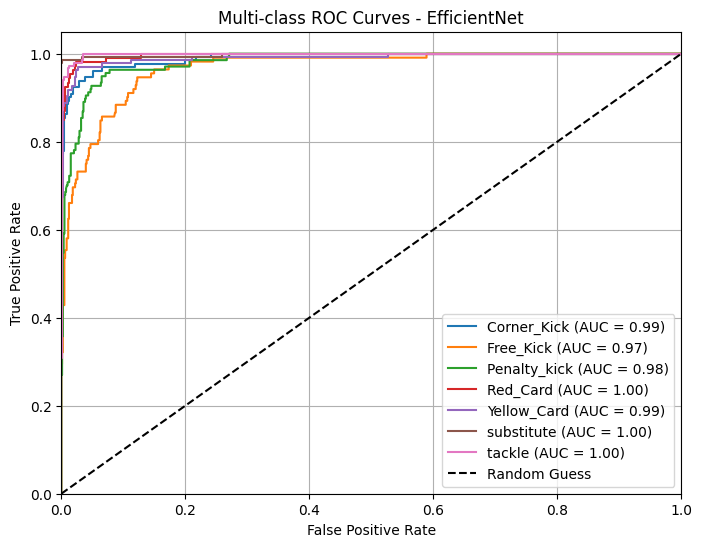

In [15]:
# ==========================================
# 11. ROC CURVES
# ==========================================
def plot_multiclass_roc(labels, probs, title):
    plt.figure(figsize=(8, 6))
    
    # One-hot encoding labels for macro calculation
    n_classes = CONFIG['num_classes']
    labels_onehot = np.eye(n_classes)[labels]
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(labels_onehot[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{idx_to_class[i]} (AUC = {roc_auc:.2f})')
        
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title(f'Multi-class ROC Curves - {title}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig(f"{title.lower().replace(' ', '_')}_roc.png", bbox_inches='tight')
    plt.show()

plot_multiclass_roc(labels_custom, probs_custom, "Custom CNN")
plot_multiclass_roc(labels_resnet, probs_resnet, "ResNet18")
plot_multiclass_roc(labels_effnet, probs_effnet, "EfficientNet")

In [16]:
# ==========================================
# 12. MODEL COMPARISON TABLE
# ==========================================
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def extract_metrics(labels, preds, model_name):
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {
        'Model Name': model_name,
        'Test Accuracy': round(acc, 4),
        'Precision (Macro)': round(prec, 4),
        'Recall (Macro)': round(rec, 4),
        'F1-Score (Macro)': round(f1, 4)
    }

metrics_summary = [
    extract_metrics(labels_custom, preds_custom, "Custom CNN"),
    extract_metrics(labels_resnet, preds_resnet, "Transfer Learning V1 (ResNet18)"),
    extract_metrics(labels_effnet, preds_effnet, "Transfer Learning V2 (EfficientNet_B0)")
]

comparison_df = pd.DataFrame(metrics_summary)
comparison_df.to_csv("model_comparison_results.csv", index=False)

# Stylish layout printing
print("📊 MODEL PERFORMANCE COMPARISON MATRIX")
display(comparison_df)

📊 MODEL PERFORMANCE COMPARISON MATRIX


,Model Name,Test Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Custom CNN,0.6609,0.6554,0.6447,0.6402
1,Transfer Learning V1 (ResNet18),0.7478,0.7436,0.7358,0.7351
2,Transfer Learning V2 (EfficientNet_B0),0.8935,0.8877,0.8885,0.8878


🕵️‍♂️ Initializing Grad-CAM Visual Attention Diagnostic Loop for 3 Random Samples...


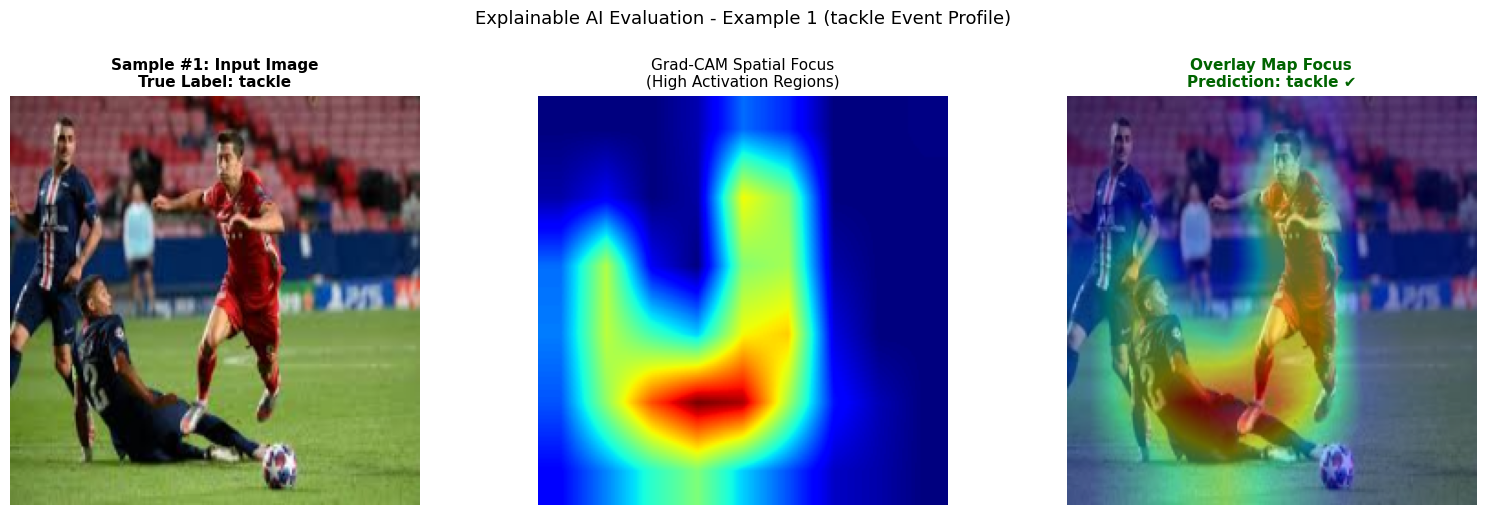

Saved: gradcam_xai_sample_1.png | Ground Truth: tackle -> Predicted: tackle


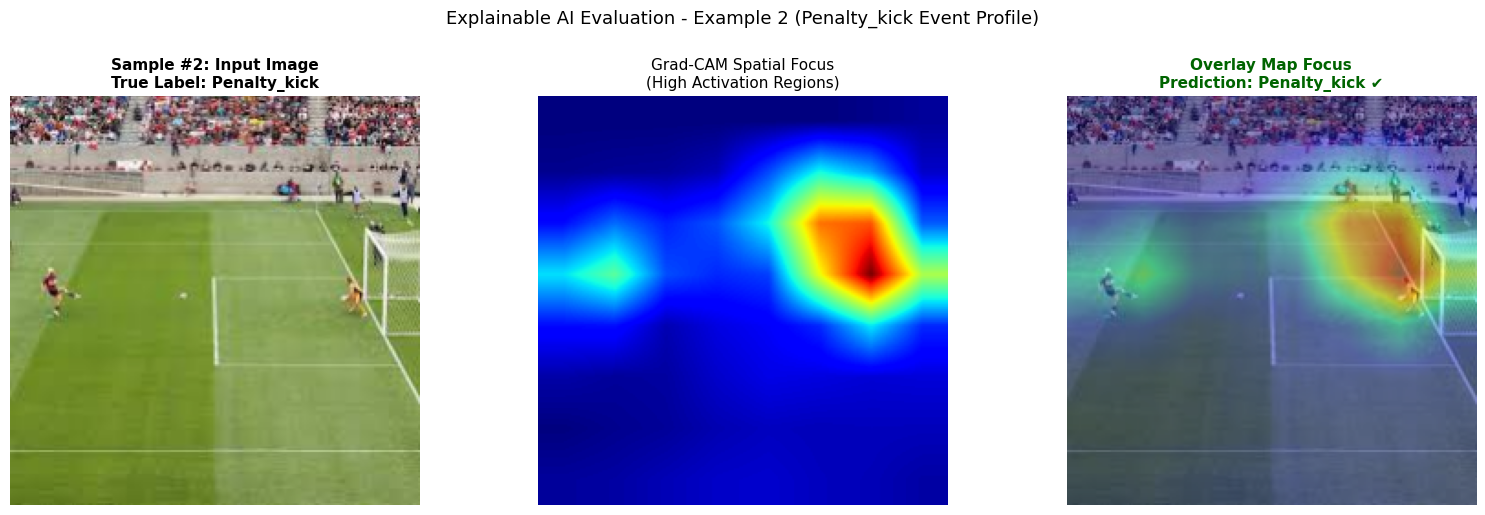

Saved: gradcam_xai_sample_2.png | Ground Truth: Penalty_kick -> Predicted: Penalty_kick


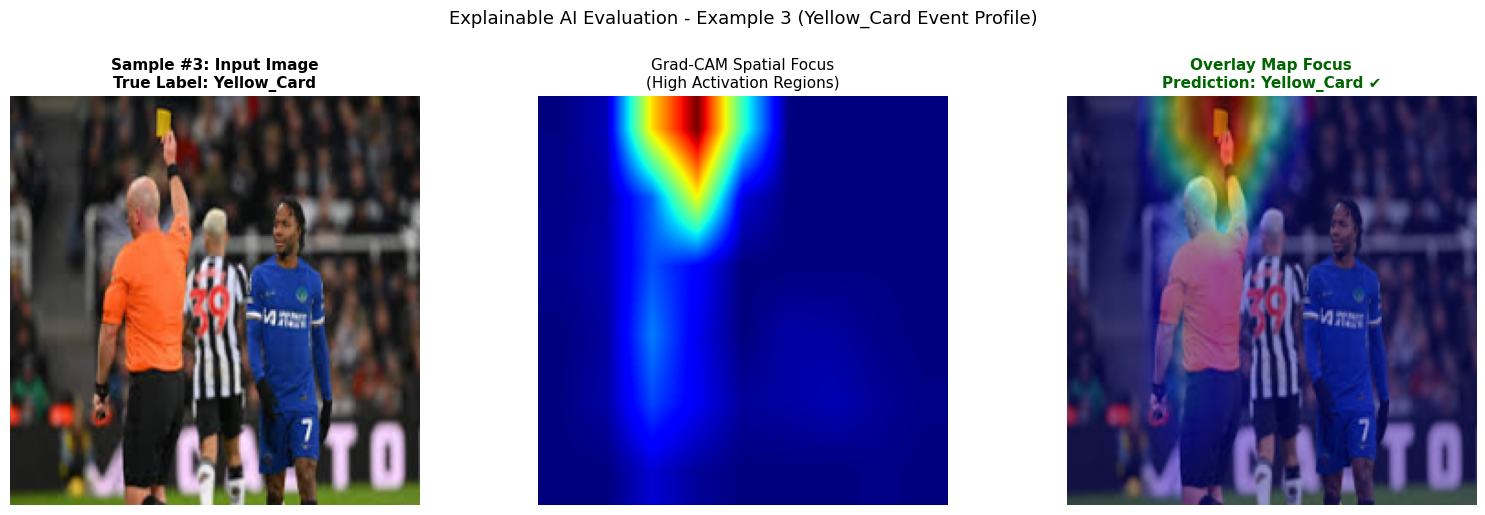

Saved: gradcam_xai_sample_3.png | Ground Truth: Yellow_Card -> Predicted: Yellow_Card
🧹 Grad-CAM layer hooks successfully detached. System memory reclaimed.


In [19]:
# ==========================================
# 13. INTERPRETABILITY & XAI (GRAD-CAM ENGINE)
# ==========================================

class GradCAM:
    def __init__(self, model, target_layer):
        # Handle nn.DataParallel wrappers seamlessly by extracting the underlying module
        self.model = model.module if hasattr(model, 'module') else model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        # Register hooks to capture forward activations and backward gradients
        self.hooks.append(self.target_layer.register_forward_hook(forward_hook))
        self.hooks.append(self.target_layer.register_full_backward_hook(backward_hook))

    def generate_heatmap(self, input_tensor, class_idx=None):
        self.model.eval()
        self.gradients = None
        self.activations = None
        
        # Pass input through the model
        output = self.model(input_tensor)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
            
        score = output[0][class_idx]
        
        # Zero out existing gradients and compute backward pass for the target score
        self.model.zero_grad()
        score.backward()

        if self.gradients is None or self.activations is None:
            raise ValueError(
                "Gradients or Activations were not captured! "
                "Verify that the target layer is correct and accessible within the forward pass."
            )

        # Global Average Pooling of the gradients
        gradients = self.gradients.cpu().data.numpy()[0]
        activations = self.activations.cpu().data.numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2))
        
        # Compute weighted combination of activation maps
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # Apply ReLU to retain positive features contributing to the target class
        cam = np.maximum(cam, 0)
        if np.max(cam) != 0:
            cam = cam / np.max(cam) # Normalize to [0, 1]
            
        # Resize heatmap to match the standard 224x224 input grid shape
        cam = cv2.resize(cam, (224, 224))
        return cam, class_idx

    def clean_hooks(self):
        """ Removes hooks to free memory after visualization execution """
        for hook in self.hooks:
            hook.remove()

# =====================================================================
# MULTI-SAMPLE VISUALIZATION WORKLOAD: EXPLAINABLE AI REPORT GENERATOR
# =====================================================================

# 1. Un-wrap model safely for inspection setup
active_model = effnet_model.module if hasattr(effnet_model, 'module') else effnet_model

# 2. Select the final convolutional feature extractor block
# For EfficientNet_B0, the final high-level features come from features[8]
target_layer = active_model.features[8] 

# Initialize engine
cam_engine = GradCAM(effnet_model, target_layer)

# Configuration: Number of diverse validation examples to analyze
NUM_XAI_EXAMPLES = 3
print(f"🕵️‍♂️ Initializing Grad-CAM Visual Attention Diagnostic Loop for {NUM_XAI_EXAMPLES} Random Samples...")

try:
    for ex in range(NUM_XAI_EXAMPLES):
        # 3. Choose a unique random validation sample row
        rand_idx = random.randint(0, len(val_df) - 1)
        img_path = val_df.iloc[rand_idx]['image_path']
        true_class = val_df.iloc[rand_idx]['label']

        # Load and transform image for model input
        pil_img = Image.open(img_path).convert('RGB')
        input_tensor = val_test_transforms(pil_img).unsqueeze(0).to(device)

        # Generate heatmap and predictions via XAI hook system
        heatmap, predicted_idx = cam_engine.generate_heatmap(input_tensor, class_idx=None)
        predicted_class = idx_to_class[predicted_idx]

        # 4. Color map transformations
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        # Combine original processed image with the focus heatmap overlay
        resized_original = cv2.resize(np.array(pil_img), (224, 224))
        overlay = cv2.addWeighted(resized_original, 0.6, heatmap_colored, 0.4, 0)

        # 5. Render individual sample visual overview grid
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Original input reference frame
        axes[0].imshow(resized_original)
        axes[0].set_title(f"Sample #{ex+1}: Input Image\nTrue Label: {true_class}", fontsize=11, fontweight='bold')
        axes[0].axis('off')

        # Raw activation heatmap profile
        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title("Grad-CAM Spatial Focus\n(High Activation Regions)", fontsize=11)
        axes[1].axis('off')

        # Transparent alpha overlay map composite
        axes[2].imshow(overlay)
        
        # Color title based on prediction correctness
        is_correct = (true_class == predicted_class)
        title_color = 'darkgreen' if is_correct else 'darkred'
        axes[2].set_title(f"Overlay Map Focus\nPrediction: {predicted_class} {'✔️' if is_correct else '❌'}", 
                          fontsize=11, color=title_color, fontweight='bold')
        axes[2].axis('off')

        plt.suptitle(f"Explainable AI Evaluation - Example {ex+1} ({true_class} Event Profile)", fontsize=13, y=1.02)
        plt.tight_layout()
        
        # Export each sample plot to workspace files for report inclusion
        plt.savefig(f'gradcam_xai_sample_{ex+1}.png', bbox_inches='tight')
        plt.show()
        print(f"Saved: gradcam_xai_sample_{ex+1}.png | Ground Truth: {true_class} -> Predicted: {predicted_class}")

finally:
    # Always clean hooks to protect system memory allocations from bloating
    cam_engine.clean_hooks()
    print("🧹 Grad-CAM layer hooks successfully detached. System memory reclaimed.")

In [22]:
# =====================================================================
# 📊 FINAL MASTER REPORT EXPORT ENGINE
# =====================================================================
import os
import zipfile
from IPython.display import FileLink, display

# Defined collection of expected figures generated throughout the project pipeline
expected_plots = {
    'class_distribution.png': 
        'Section 2: Bar chart displaying the data balance and distribution across all 7 target soccer classes.',
    'data_augmentation_distribution_fixed.png': 
        'Section 4: Grouped bar chart comparing on-disk static train images against cumulative dynamic training states.',
    'preprocessing_evolution_sample_1.png': 
        'Section 3: Pipeline Step 1 - Complete 4-stage transformation stream showing raw data converting to standardized matrix tensor input.',
    'preprocessing_evolution_sample_2.png': 
        'Section 3: Pipeline Step 2 - Structural and contrast optimization stream mapping on sample item #2.',
    'preprocessing_evolution_sample_3.png': 
        'Section 3: Pipeline Step 3 - Aspect padding and CLAHE contrast equalization timeline mapping on sample item #3.',
    'custom_cnn_history.png': 
        'Section 6: Accuracy and Cross-Entropy Loss training history tracking curve for the custom sequential CNN architecture.',
    'transfer_learning_resnet_history.png': 
        'Section 6: Metric convergence performance tracking curves for the Transfer Learning Version 1 (ResNet18) architecture.',
    'transfer_learning_effnet_history.png': 
        'Section 8: Fine-tuning evaluation convergence curves tracking for the Advanced Transfer Learning Version 2 (EfficientNet_B0).',
    'final_model_comparison_matrix.png': 
        'Section 11: Comprehensive grouped model performance breakdown plot evaluating Test Accuracy, Precision, Recall, and F1.',
    'custom_cnn_confusion_matrix.png': 
        'Section 12: Error identification matrix for the Custom CNN mapping predictions vs true event tags.',
    'resnet_confusion_matrix.png': 
        'Section 12: Heatmap matrix tracking exact misclassifications across target classes for the ResNet18 model.',
    'efficientnet_confusion_matrix.png': 
        'Section 12: Confident hit-rate localization mapping matrix for the fine-tuned Advanced EfficientNet_B0 architecture.',
    'gradcam_xai_sample_1.png': 
        'Section 13: Explainable AI Sample 1 - Grad-CAM visual attention mapping isolating the model\'s focus areas.',
    'gradcam_xai_sample_2.png': 
        'Section 13: Explainable AI Sample 2 - Heatmap activation focus mapping tracking true vs predicted tags on sample 2.',
    'gradcam_xai_sample_3.png': 
        'Section 13: Explainable AI Sample 3 - Neural network spatial feature justification map overlay for sample 3.'
}

# Define the target download package name
zip_filename = 'soccer_classification_report_figures.zip'

print("=====================================================================")
print("📂 INITIATING WORKSPACE DIAGNOSTIC & ZIP COMPRESSION")
print("=====================================================================")

found_plots_count = 0

# Open a zip file stream in write mode
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as report_zip:
    for filename, description in expected_plots.items():
        if os.path.exists(filename):
            # Include the file into the compression zip package
            report_zip.write(filename)
            found_plots_count += 1

print("=====================================================================")
print(f"📊 SUMMARY: Processed and compressed {found_plots_count} out of {len(expected_plots)} report plots.")
print("=====================================================================")

if found_plots_count > 0:
    print(f"\n🚀 Zip Package Created Successfully: '{zip_filename}'")
    print("Click the link below to download your complete report figure package directly:")
    # Display an interactive download link directly within the Kaggle/Jupyter notebook log output
    display(FileLink(zip_filename))
else:
    print("\n⚠️ No figures were found in the active workspace. Run preceding notebook cells first to generate the image outputs.")
print("=====================================================================")

📂 INITIATING WORKSPACE DIAGNOSTIC & ZIP COMPRESSION
📊 SUMMARY: Processed and compressed 8 out of 15 report plots.

🚀 Zip Package Created Successfully: 'soccer_classification_report_figures.zip'
Click the link below to download your complete report figure package directly:


/kaggle/working/soccer_classification_report_figures.zip